# Case Study 1: SuperConducter 
Johnny Vogt

# Goals and Requirements
1. 2 Logistic Regression Model (L1 and L2 Regularization)
2. Top 10 Variable importance
3. Discussion of Results

# Data
train.csv - Training set, quick look at excel shows that there are 82 columns and 21,263 Rows.
- RESPONSE is criticaltemp (Kelvin)

unique_m.csv - The "metadata" file that was mentioned in the casestudy videos, I think? Basically looks like a the periodic table as columns + 2 columns for the critical temp for each material.
-  I think row 1 in train.csv matches up with row 1 in unique_m.csv

# Data Reference
## General Count
number_of_elements: Count of distinct elements in the compound

## General Stats across for my own edification and understanding
### These measurements are repeated over and over for multiple attributes
mean: Simple, Average
wtd_mean: Weghted Mean, weighted by proportion
gmean: geometric mean
wtd_gmean: Weighted G Mean, elemental proportions are used as weights
entropy: entropy of distribution, higher the value the spread out the property is
wtd_entropy: weighted version of the entropy value 
range: max - min
wtd_range: weighted range, i might need to how exactly this works
std: Standard Devianstion of the property
wtd_std: Another weighted standard deviantion

## Features 
Atomic Mass - Its the atomic mass i.e. Hydrogen:1 Helium:2 etc.
fie (First Ionization Energy) - Energy needed to remove the first electron
Atomic Raidus - how big the atoms are
Density - Mass per volume, combined between all the elementes
Electron Affinity - how strongly the elements tend to gain an electron
Fusion Heat: Energy to melt a solid
Thermal Conductivity: How well the material conduct heat/electricity
Valence: how many bonding each element contributes...stickiness

# Response
critical temp: when the material becomes superconducting


In [28]:
# Libraries 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
# Loading in the Data
supertrain = pd.read_csv('C:\\Users\\Owner\\git\\School\\MSDS7333 Quantifying\\Case Studies\\Superconductor\\superconduct\\train.csv')
umater = pd.read_csv('C:\\Users\\Owner\\git\\School\\MSDS7333 Quantifying\\Case Studies\\Superconductor\\superconduct\\unique_m.csv')


In [ ]:
# Data Exploration - Cleaning, If needed
# Shape
print("Shape of the datasets:")
print("supertrain", supertrain.shape)
print("umater", umater.shape)

# Missing Values
print("\nChecking for missing values:")
print("supertrain", supertrain.isnull().sum().sum())
print("umater", umater.isnull().sum().sum())

## Looks like there are no missing values in either dataset.

# Data Types  
print("\nData types of the datasets:")
print("\nSuperconductor Train Dataset:")
print("supertrain", supertrain.dtypes)
print("\nUnique Materials Dataset:")
print("umater", umater.dtypes)

# supertrain: Most things are float64, range is int64
# umater: Almost are all are int64, except critical_temp which is float64 and materal which is object.

# Quck duplicate check on materials
print("\nChecking for duplicate materials in umater:")
duplicate_materials = umater['material'].duplicated().sum()
print("Number of duplicate materials:", duplicate_materials)
# There are 5721 Duplicates. Need to see if they are exact duplicates or if there are different critical temperatures for the same material.
material_counts = umater['material'].value_counts()
duplicate_materials_count = material_counts[material_counts > 1]
print("\nMaterials with duplicates and their counts:")
print(duplicate_materials_count.head(10))  # Show top 10 materials with duplicates

# If each material has the same critical temperature, then we should be able to drop them. If not, (╯°□°）╯︵ ┻━┻

uniq_temps_mater = (umater.groupby('material')['critical_temp'].nunique())
inconsitent_materials = uniq_temps_mater[uniq_temps_mater > 1]
print("\nNumber of unique critical temperature ")
print("Number of materials with inconsistent critical temperatures:", len(inconsitent_materials))
print("\nMaterials with inconsistent critical temperatures:")
print(inconsitent_materials.head(10)) 


# Alright, we have 5721 doops, but about 2261 of them have inconsistent crit temps, so we dont have to drop. But the other 3000ish, we need to check against supertrain to see if they have the same exact measurement.

# index alignment check
# Same number of rows. This is gonna get confusing. LOL
print("supertrain shape:", supertrain.shape)
print("umater shape:", umater.shape)

# Attaching umater with supertrain for easier comparison
supertrain_umater= supertrain.copy()
supertrain_umater['material'] = umater['material']

# Doop Check in combined dataset
feature_cols = [c for c in supertrain_umater.columns if c not in ['critical_temp', 'material']]
dup_key_feats = feature_cols +['critical_temp', 'material']
identical_doops = supertrain_umater.duplicated(subset=dup_key_feats).sum()
print("\nNumber of identical doops in combined dataset:", identical_doops)

# Soo it looks like each duplicate was probably a different experiment for the same material. So we should keep them all. Very roundabout way to check, but it works.



Shape of the datasets:
supertrain (21263, 82)
umater (21263, 88)

Checking for missing values:
supertrain 0
umater 0

Data types of the datasets:

Superconductor Train Dataset:
supertrain number_of_elements         int64
mean_atomic_mass         float64
wtd_mean_atomic_mass     float64
gmean_atomic_mass        float64
wtd_gmean_atomic_mass    float64
                          ...   
range_Valence              int64
wtd_range_Valence        float64
std_Valence              float64
wtd_std_Valence          float64
critical_temp            float64
Length: 82, dtype: object

Unique Materials Dataset:
umater H                float64
He                 int64
Li               float64
Be               float64
B                float64
                  ...   
Po                 int64
At                 int64
Rn                 int64
critical_temp    float64
material          object
Length: 88, dtype: object

Checking for duplicate materials in umater:
Number of duplicate materials: 5721

Materi

count    21263.000000
mean        34.421219
std         34.254362
min          0.000210
25%          5.365000
50%         20.000000
75%         63.000000
max        185.000000
Name: critical_temp, dtype: float64


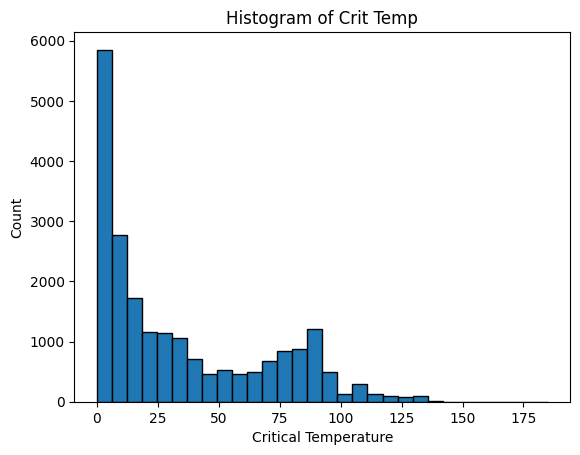

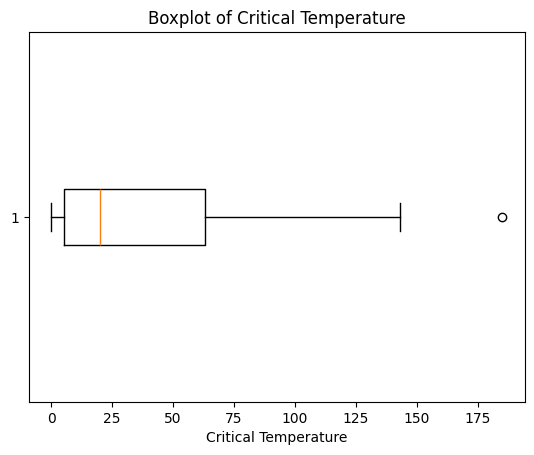


Positive correlations with critical temperature:

critical_temp                  1.000000
wtd_std_ThermalConductivity    0.721271
range_ThermalConductivity      0.687654
range_atomic_radius            0.653759
std_ThermalConductivity        0.653632
wtd_entropy_atomic_mass        0.626930
wtd_entropy_atomic_radius      0.603494
number_of_elements             0.601069
range_fie                      0.600790
wtd_std_atomic_radius          0.599199
entropy_Valence                0.598591
Name: critical_temp, dtype: float64

Negative correlations with critical temperature:

gmean_FusionHeat       -0.431795
wtd_gmean_FusionHeat   -0.432365
wtd_mean_Density       -0.433940
wtd_range_Valence      -0.439901
wtd_gmean_Density      -0.540046
gmean_Density          -0.541684
gmean_Valence          -0.573068
mean_Valence           -0.600085
wtd_gmean_Valence      -0.615653
wtd_mean_Valence       -0.632401
Name: critical_temp, dtype: float64


In [43]:
#  EDA - Criit Temp
print(supertrain['critical_temp'].describe())
# A Histogram. Looks like most of the crit temps are below  50, but there are a signifcant number that goes well above 50. 
plt.hist(supertrain['critical_temp'], bins=30, edgecolor='black')
plt.xlabel('Critical Temperature')
plt.ylabel('Count')
plt.title('Histogram of Crit Temp')
plt.show()

#Boxplot
plt.boxplot(supertrain['critical_temp'], vert=False)
plt.xlabel('Critical Temperature')
plt.title('Boxplot of Critical Temperature')
plt.show()

#Correlation with other features
corr_supertrain = supertrain.corr(numeric_only=True) 
corr_critical_temp = corr_supertrain['critical_temp'].sort_values(ascending=False)
print("\nPositive correlations with critical temperature:\n")
print(corr_critical_temp.head(11))
print("\nNegative correlations with critical temperature:\n")
print(corr_critical_temp.tail(10))


# Correlationssss
Just off the name and correlation value, you can see that theres likely alot of multicollinearity. Probbably would need to do a Lasso to slim down the training features in the model. 